## Install libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [1]:
# Core
%pip install pymupdf pymupdf4llm --quiet
%pip install jiwer python-Levenshtein --quiet
%pip install pandas openpyxl --quiet

# Open-source extractors
%pip install docling --quiet
%pip install unstructured[all-docs] --quiet
%pip install marker-pdf --quiet

'''# Commercial (need API keys)
%pip install llama-parse --quiet
%pip install azure-ai-documentintelligence --quiet
%pip install boto3 --quiet
%pip install mistralai --quiet '''

print("Libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.9/522.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.6/285.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 64.6 MB/s eta 0:00:00
   ━━━━

## Imports and paths

In [21]:
path = Path("/content/drive/MyDrive/PDF_Data_Extraction/outputs/docling/5_ibm-annual-report-2025/images")

print(path.exists())
print(path.is_dir())
print(path.is_file())

True
False
True


In [22]:
path.unlink()   # delete file
path.mkdir(parents=True, exist_ok=True)

In [4]:
import os, io, re, csv, time, json, warnings
import pandas as pd
from pathlib import Path
from PIL import Image
import fitz
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── PDF path ──────────────────────────────────────────────────────
pdf_path = "/content/drive/MyDrive/PDF_Data_Extraction/corpus/1_Rapport-financier-semestriel-AFD-2025.pdf"

# ── Root output folder in Drive ───────────────────────────────────
output_base = Path("/content/drive/MyDrive/PDF_Data_Extraction/outputs")

# ── API keys ──────────────────────────────────────────────────────
try:
    from google.colab import userdata
    LLAMA_KEY   = userdata.get("LLAMA_CLOUD_API_KEY") or ""
    MISTRAL_KEY = userdata.get("MISTRAL_API_KEY")     or ""
    AZURE_EP    = userdata.get("AZURE_DI_ENDPOINT")   or ""
    AZURE_KEY   = userdata.get("AZURE_DI_KEY")        or ""
except Exception:
    LLAMA_KEY = MISTRAL_KEY = AZURE_EP = AZURE_KEY = ""

pdf_path = Path(pdf_path)
pdf_stem = pdf_path.stem
assert pdf_path.exists(), f"PDF not found: {pdf_path}"

# ── Helper: returns the output folder for a given tool ────────────
# Structure: outputs/{tool_name}/{pdf_stem}/text|tables|images
def tool_dir(tool_name: str) -> Path:
    return output_base / tool_name / pdf_stem

def make_tool_folders(tool_name: str) -> dict:
    "Create and return all subfolders for one tool."
    base   = tool_dir(tool_name)
    folders = {
        "base"   : base,
        "text"   : base / "text",
        "tables" : base / "tables",
        "images" : base / "images",
        "scores" : base / "scores",
    }
    for p in folders.values():
        p.mkdir(parents=True, exist_ok=True)
    return folders

# ── Ground truth folder ───────────────────────────────────────────
GT_DIR = output_base / "ground_truth" / pdf_stem
GT_DIR.mkdir(parents=True, exist_ok=True)

# ── Create folders for every tool now so nothing breaks later ─────
TOOL_NAMES = [
    "pymupdf4llm", "docling", "unstructured",
    "marker", "llama_parse", "azure_di", "mistral_ocr"
]
for t in TOOL_NAMES:
    make_tool_folders(t)

# ── Quick PDF summary ─────────────────────────────────────────────
doc = fitz.open(str(pdf_path))
n_pages      = doc.page_count
total_chars  = sum(len(p.get_text()) for p in doc)
total_images = sum(len(p.get_images()) for p in doc)
doc.close()

print(f"PDF      : {pdf_path.name}")
print(f"Pages    : {n_pages}")
print(f"Chars    : {total_chars:,}")
print(f"Images   : {total_images}")
print()
print("Output folder structure created in Drive:")
print(f"  {output_base}")
for t in TOOL_NAMES:
    print(f"  └── {t}/{pdf_stem}/  (text/ tables/ images/ scores/)")

PDF      : 1_Rapport-financier-semestriel-AFD-2025.pdf
Pages    : 53
Chars    : 150,986
Images   : 2

Output folder structure created in Drive:
  /content/drive/MyDrive/PDF_Data_Extraction/outputs
  └── pymupdf4llm/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── docling/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── unstructured/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── marker/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── llama_parse/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── azure_di/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)
  └── mistral_ocr/1_Rapport-financier-semestriel-AFD-2025/  (text/ tables/ images/ scores/)


## Ground truth

In [ ]:
# ── Choose which pages to use as ground truth ─────────────────────
GT_TEXT_PAGE  = 2    # page number for text evaluation (1-based)
GT_TABLE_PAGE = 15   # page number for table evaluation (1-based)

# ── Auto-extract text from GT_TEXT_PAGE ───────────────────────────
doc   = fitz.open(str(pdf_path))
page  = doc[GT_TEXT_PAGE - 1]
pw    = page.rect.width

raw_blocks = page.get_text("blocks")   # (x0, y0, x1, y1, text, block_no, block_type)

# Two-column aware sort: detect if page has two columns
left_blocks  = [b for b in raw_blocks if b[0] < pw / 2]
right_blocks = [b for b in raw_blocks if b[0] >= pw / 2]
is_two_col   = len(left_blocks) > 2 and len(right_blocks) > 2

if is_two_col:
    sorted_blocks = (
        sorted(left_blocks,  key=lambda b: b[1]) +
        sorted(right_blocks, key=lambda b: b[1])
    )
else:
    sorted_blocks = sorted(raw_blocks, key=lambda b: (round(b[1]/20)*20, b[0]))

# Deduplicate
seen, clean_blocks = set(), []
for b in sorted_blocks:
    txt = re.sub(r"\s+", " ", b[4]).strip()
    if txt and txt.lower() not in seen:
        seen.add(txt.lower())
        clean_blocks.append(b)

gt_text_draft = "".join(b[4].strip() for b in clean_blocks if b[4].strip())
doc.close()

# Save text ground truth
gt_text_path = GT_DIR / f"gt_text_page{GT_TEXT_PAGE}.md"
gt_text_path.write_text(gt_text_draft, encoding="utf-8")

print(f"Text ground truth saved to Drive:")
print(f"  {gt_text_path}")
print(f"Preview (first 800 chars):")
print("-" * 50)
print(gt_text_draft[:800])
print("-" * 50)

Text ground truth saved to Drive:
  /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/ground_truth/4_scanned_document/gt_text_page1.md
Preview (first 800 chars):
--------------------------------------------------
EXAMPLE
--------------------------------------------------


In [ ]:
# ── Auto-extract table from GT_TABLE_PAGE ─────────────────────────
doc   = fitz.open(str(pdf_path))
page  = doc[GT_TABLE_PAGE - 1]

tables_found = page.find_tables()
doc.close()

gt_table_path = GT_DIR / f"gt_table_page{GT_TABLE_PAGE}.csv"

if tables_found:
    # Take the largest table on the page
    biggest = max(tables_found, key=lambda t: len(t.extract()) * len(t.extract()[0]) if t.extract() else 0)
    raw_rows = biggest.extract()
    gt_table_draft = [[c if c else "" for c in row] for row in raw_rows]

    with open(gt_table_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerows(gt_table_draft)

    print(f"Table ground truth auto-extracted ({len(gt_table_draft)} rows).")
    print(f"Saved to Drive: {gt_table_path}")
    print(f"Preview:")
    print(pd.DataFrame(gt_table_draft).to_string(index=False, header=False))

else:
    # No table detected — write a blank template
    print("No table auto-detected on this page.")
    print("Writing a blank template — fill it in manually in Google Drive.")
    gt_table_draft = [
        ["Column 1", "Column 2", "Column 3", "Column 4", "Column 5"],
        ["", "", "", "", ""],
        ["", "", "", "", ""],
    ]
    with open(gt_table_path, "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerows(gt_table_draft)
    print(f"Blank template saved to: {gt_table_path}")


IndexError: page 14 not in document

In [24]:
# Load ground truth from Drive
def load_gt_text():
    p = GT_DIR / f"gt_text_page{GT_TEXT_PAGE}.md"
    return p.read_text(encoding="utf-8").strip() if p.exists() else ""

'''def load_gt_table():
    p = GT_DIR / f"gt_table_page{GT_TABLE_PAGE}.csv"
    if not p.exists():
        return []
    with open(p, newline="", encoding="utf-8") as f:
        return list(csv.reader(f))'''

GT_TEXT  = load_gt_text()
GT_TABLE = load_gt_table()

print(f"Ground truth text  : {len(GT_TEXT)} chars loaded")
print(f"Ground truth table : {len(GT_TABLE)} rows loaded")


NameError: name 'GT_TEXT_PAGE' is not defined

## Scoring functions (CER + TEDS)

In [29]:
from jiwer import cer as jiwer_cer
import Levenshtein
import csv

ALL_SCORES = []   # collects one dict per tool

def load_gt_text() -> str:
    p = GT_DIR / f"gt_text_page{GT_TEXT_PAGE}.md"
    return p.read_text(encoding="utf-8").strip() if p.exists() else ""

def load_gt_table() -> list:
    p = GT_DIR / f"gt_table_page{GT_TABLE_PAGE}.csv"
    if not p.exists():
        return []
    with open(p, newline="", encoding="utf-8") as f:
        return list(csv.reader(f))


def _extract_gt_window(full_text: str, gt_text: str, window_chars: int = 3000) -> str:
    """
    Return the slice of full_text that best overlaps with gt_text.
    Strategy: slide a window of `window_chars` chars and pick the one with the
    lowest CER against gt_text.  Falls back to the full text if gt_text is short.
    """
    if not full_text or not gt_text:
        return full_text
    # If the full doc is shorter than 2× the window, just return it as-is
    if len(full_text) <= window_chars * 2:
        return full_text
    # Build candidate windows every 500 chars
    best_window, best_cer = full_text, 1.0
    step = 500
    for start in range(0, max(1, len(full_text) - window_chars), step):
        window = full_text[start: start + window_chars]
        try:
            c = jiwer_cer(
                re.sub(r"\s+", " ", gt_text.strip()),
                re.sub(r"\s+", " ", window.strip()),
            )
        except Exception:
            continue
        if c < best_cer:
            best_cer = c
            best_window = window
    return best_window


def compute_cer(full_extracted: str, reference: str) -> float:
    """
    Character Error Rate — 0.0 = perfect, lower is better.
    Automatically finds the best-matching window in full_extracted
    so the score is not inflated by unrelated pages.
    """
    ref = re.sub(r"\s+", " ", reference.strip())
    if not ref:
        return 0.0
    window = _extract_gt_window(full_extracted, ref)
    hyp = re.sub(r"\s+", " ", window.strip())
    if not hyp:
        return 1.0
    return round(jiwer_cer(ref, hyp), 4)


def compute_teds(pred_table: list, gt_table: list) -> float:
    """Table similarity 0.0–1.0. 1.0 = perfect match. Higher is better."""
    if not gt_table:
        return None   # return None instead of 1.0 so we don't show a fake score
    if not pred_table:
        return 0.0
    def to_string(table):
        rows = []
        for row in table:
            cells = "".join(f"(td {str(c).strip()})" for c in row)
            rows.append(f"(tr {cells})")
        return f"(table {chr(39).join(rows)})"
    s1 = to_string(pred_table)
    s2 = to_string(gt_table)
    dist = Levenshtein.distance(s1, s2)
    return round(1.0 - dist / max(len(s1), len(s2)), 4)


def stars(val, metric):
    if metric == "cer":
        thresholds = [(0.05, 5), (0.10, 4), (0.20, 3), (0.40, 2)]
        return next(("★"*s + "☆"*(5-s) for t, s in thresholds if val <= t), "★☆☆☆☆")
    else:
        thresholds = [(0.95, 5), (0.85, 4), (0.70, 3), (0.50, 2)]
        return next(("★"*s + "☆"*(5-s) for t, s in thresholds if val >= t), "★☆☆☆☆")


def show_scores(tool_name, full_text, pred_table, elapsed, cost_note="free"):
    """
    Call with the FULL document text (not just one page).
    The function will find the best-matching window against GT automatically.
    """
    gt_text  = load_gt_text()
    gt_table = load_gt_table()

    cer  = compute_cer(full_text, gt_text) if gt_text else None
    teds = compute_teds(pred_table, gt_table)   # None if no GT table

    print()
    print("┌" + "─" * 55 + "┐")
    print(f"│  SCORES — {tool_name:<44}│")
    print("├" + "─" * 55 + "┤")
    if cer is not None:
        print(f"│  CER  (text)  : {cer:.4f}   {stars(cer,  'cer' ):<12}              │")
    else:
        print(f"│  CER  (text)  : N/A  (no ground-truth text)         │")
    if teds is not None:
        print(f"│  TEDS (table) : {teds:.4f}   {stars(teds, 'teds'):<12}              │")
    else:
        print(f"│  TEDS (table) : N/A  (no ground-truth table)        │")
    print(f"│  Time         : {elapsed:.1f}s" + " "*39 + "│")
    print(f"│  Cost         : {cost_note:<39}│")
    print("└" + "─" * 55 + "┘")
    print("  CER:  0.0=perfect · <0.10=good · >0.30=poor")
    print("  TEDS: 1.0=perfect · >0.85=good · <0.50=poor")

    row = {
        "tool"  : tool_name,
        "CER"   : cer  if cer  is not None else "N/A",
        "TEDS"  : teds if teds is not None else "N/A",
        "time_s": round(elapsed, 1),
        "cost"  : cost_note,
    }
    ALL_SCORES.append(row)

    # Save individual score JSON to Drive
    score_path = tool_dir(tool_name.lower().replace(" ", "_")) / "scores" / "scores.json"
    score_path.parent.mkdir(parents=True, exist_ok=True)
    with open(score_path, "w") as f:
        json.dump(row, f, indent=2)
    return row

print("✅ Scoring functions ready (CER window-search + TEDS with GT table).")

✅ Scoring functions ready (CER window-search + TEDS with GT table).


## Tool 1 · PyMuPDF4LLM
**Licence:** AGPL / commercial  
**Best for:** Fast baseline, native PDF text, no ML required  

In [28]:
import fitz
import pymupdf4llm

TOOL = "pymupdf4llm"
dirs = make_tool_folders(TOOL)

t0  = time.perf_counter()
doc = fitz.open(str(pdf_path))

# ── Text — save each page as a separate .md file ──────────────────
full_md_text = pymupdf4llm.to_markdown(str(pdf_path))

# Split by page and save individually
page_texts = full_md_text.split("-----")   # pymupdf4llm uses ----- as page separator
for pg_i, page_text in enumerate(page_texts):
    if page_text.strip():
        out_file = dirs["text"] / f"page_{pg_i+1:03d}.md"
        out_file.write_text(page_text.strip(), encoding="utf-8")

# Also save the full document as one file
(dirs["text"] / "full_document.md").write_text(full_md_text, encoding="utf-8")

# ── Tables — save each as a separate .csv ─────────────────────────
pymupdf_tables = []
table_count = 0
for page in doc:
    for tbl in page.find_tables():
        rows = [[c if c else "" for c in row] for row in tbl.extract()]
        pymupdf_tables.append({"page": page.number + 1, "data": rows})
        csv_file = dirs["tables"] / f"page_{page.number+1:03d}_table_{table_count+1}.csv"
        with open(csv_file, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerows(rows)
        table_count += 1

# ── Images — save each image ──────────────────────────────────────
saved_imgs = []
for pg_i, page in enumerate(doc):
    for im_i, img_info in enumerate(page.get_images(full=True)):
        xref = img_info[0]
        base = doc.extract_image(xref)
        dest = dirs["images"] / f"page_{pg_i+1:03d}_img_{im_i+1}.{base['ext']}"
        dest.write_bytes(base["image"])
        saved_imgs.append(str(dest))
doc.close()

elapsed_pymupdf = time.perf_counter() - t0

print(f"Time   : {elapsed_pymupdf:.1f}s")
print(f"Pages  : {len(page_texts)} text files saved")
print(f"Tables : {table_count} CSV files saved")
print(f"Images : {len(saved_imgs)} files saved")
print()
print(f"All output in Drive:")
print(f"  Text   → {dirs['text']}")
print(f"  Tables → {dirs['tables']}")
print(f"  Images → {dirs['images']}")
print()
print("── Text preview (first 600 chars) ──")
print(full_md_text[:600])

=== Document parser messages ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Using Tesseract for OCR processing.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=4/5.
OCR on page.number=123/124.

Time   : 288.7s
Pages  : 33 text files saved
Tabl

In [21]:
# ── Table preview ─────────────────────────────────────────────────
if pymupdf_tables:
    t = pymupdf_tables[0]
    print(f"First table (page {t['page']}, {len(t['data'])} rows):")
    print(pd.DataFrame(t["data"]).to_string(index=False, header=False))
else:
    print("No tables found.")

First table (page 7, 30 rows):
                     MANAGEMENTDISCUSSION              NOTESTOCONSOLIDATEDFINANCIALSTATEMENTS                                      
                                 Overview  6                                   Basis&Policies                                      
Forward-Looking and Cautionary Statements  7                                                A     SignificantAccountingPolicies  48
             ManagementDiscussionSnapshot  8                                                B                 AccountingChanges  62
                    DescriptionofBusiness 11                           Performance&Operations                                      
                             YearinReview 16                                                C                RevenueRecognition  63
                        PriorYearinReview 28                                                D                          Segments  65
                         OtherInformation 30 

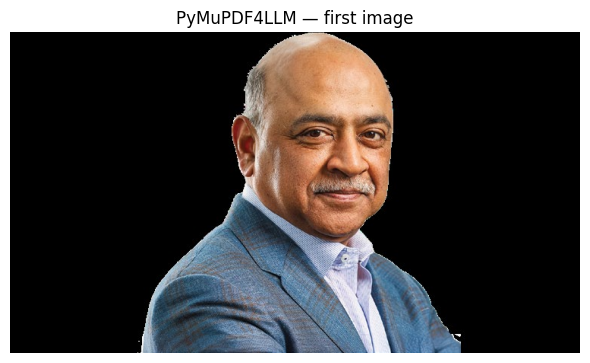

In [22]:
# ── Image preview ─────────────────────────────────────────────────
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6,4))
    plt.imshow(img); plt.axis("off")
    plt.title("PyMuPDF4LLM — first image")
    plt.tight_layout(); plt.show()
else:
    print("No raster images in this PDF.")

In [27]:
GT_TEXT_PAGE  = 2
GT_TABLE_PAGE = 7

In [30]:
# SCORES
pred_tbl = pymupdf_tables[0]["data"] if pymupdf_tables else []
show_scores(TOOL, full_md_text, pred_tbl, elapsed_pymupdf)


┌───────────────────────────────────────────────────────┐
│  SCORES — pymupdf4llm                                 │
├───────────────────────────────────────────────────────┤
│  CER  (text)  : N/A  (no ground-truth text)         │
│  TEDS (table) : N/A  (no ground-truth table)        │
│  Time         : 376.5s                                       │
│  Cost         : free                                   │
└───────────────────────────────────────────────────────┘
  CER:  0.0=perfect · <0.10=good · >0.30=poor
  TEDS: 1.0=perfect · >0.85=good · <0.50=poor


{'tool': 'pymupdf4llm',
 'CER': 'N/A',
 'TEDS': 'N/A',
 'time_s': 376.5,
 'cost': 'free'}

## Tool 2 · Docling
**Licence:** MIT (IBM)  
**Best for:** Best table structure, heading detection, multi-column layout  

In [29]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

TOOL = "docling"
dirs = make_tool_folders(TOOL)

opts = PdfPipelineOptions()
opts.do_ocr             = True
opts.do_table_structure = True

converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)}
)

t0     = time.perf_counter()
result = converter.convert(str(pdf_path))
doc_dl = result.document

# ── Text — save full document + one file per page ─────────────────
docling_text  = doc_dl.export_to_markdown()
docling_plain = doc_dl.export_to_text()

# Save full document
(dirs["text"] / "full_document.md").write_text(docling_text, encoding="utf-8")

# Save page by page
# Docling pages are accessible via doc_dl.pages
for pg in getattr(doc_dl, "pages", []):
    pg_num  = getattr(pg, "page_no", 0) + 1   # 0-based → 1-based
    pg_text = getattr(pg, "export_to_markdown", lambda: "")()
    if pg_text and pg_text.strip():
        (dirs["text"] / f"page_{pg_num:03d}.md").write_text(pg_text.strip(), encoding="utf-8")

# ── Tables — fix the deprecation warning by passing doc argument ──
docling_tables = []
for tbl_idx, tbl_item in enumerate(doc_dl.tables):
    try:
        # New API: pass doc argument to suppress deprecation warning
        df = tbl_item.export_to_dataframe(doc=doc_dl)
    except TypeError:
        # Older docling version — fall back to old call
        df = tbl_item.export_to_dataframe()

    rows = df.values.tolist()
    docling_tables.append(rows)

    # Save as CSV
    csv_file = dirs["tables"] / f"table_{tbl_idx+1:03d}.csv"
    with open(csv_file, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(list(df.columns))   # header
        writer.writerows(rows)

# ── Figures ───────────────────────────────────────────────────────
saved_imgs = []
for i, fig in enumerate(getattr(doc_dl, "pictures", [])):
    try:
        img_bytes = fig.image.as_bytes()
        dest = dirs["images"] / f"figure_{i+1:03d}.png"
        dest.write_bytes(img_bytes)
        saved_imgs.append(str(dest))
    except Exception:
        pass

elapsed_docling = time.perf_counter() - t0

print(f"Time    : {elapsed_docling:.1f}s")
print(f"Tables  : {len(docling_tables)} CSV files saved → {dirs['tables']}")
print(f"Figures : {len(saved_imgs)} files saved → {dirs['images']}")
print(f"Text    : saved → {dirs['text']}")
print()
print("── Text preview (first 600 chars) ──")
print(docling_text[:600])

[INFO] 2026-06-01 13:06:24,060 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-01 13:06:24,081 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-01 13:06:24,082 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-01 13:06:24,194 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-01 13:06:24,198 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-01 13:06:24,199 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-01 13:06:24,258 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-01 13:06:24,289 [RapidOCR] download_file.py:60: File exists and is valid: /usr

Time    : 247.3s
Tables  : 135 CSV files saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/docling/5_ibm-annual-report-2025/tables
Figures : 0 files saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/docling/5_ibm-annual-report-2025/images
Text    : saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/docling/5_ibm-annual-report-2025/text

── Text preview (first 600 chars) ──
<!-- image -->

## Let's Create Smarter Business

<!-- image -->

I

<!-- image -->

II

<!-- image -->

Arvind Krishna Chairman, President and Chief Executive Officer

<!-- image -->

## Dear IBM Investor:

IBM's strategy is built on two technology foundations: hybrid cloud and AI. Together, they unlock the full value of enterprise data and enable businesses to operate with greater intelligence, agility, and scale. We have repositioned IBM as a softwareled, fully integrated platform companycombining technology, consulting, and infrastructure. And we're investing in the platforms that will d

In [25]:
# ── Table preview ─────────────────────────────────────────────────
if docling_tables:
    print(f"First table ({len(docling_tables[0])} rows):")
    print(pd.DataFrame(docling_tables[0]).to_string(index=False, header=False))
else:
    print("No tables extracted.")

First table (28 rows):
Forward-Looking and Cautionary Statements  7             A Significant Accounting Policies  48
           Management Discussion Snapshot  8                          B Accounting Changes  62
                  Description of Business 11                       Performance &Operations    
                           Year in Review 16                         C Revenue Recognition  63
                     Prior Year in Review 28                                    D Segments  65
                        Other Information 30                 E Acquisitions & Divestitures  69
                          Looking Forward 30                  F Other (Income) and Expense  73
          Liquidity and Capital Resources 31                                       G Taxes  74
            Critical Accounting Estimates 34                          H Earnings Per Share  78
               Currency Rate Fluctuations 36                      Balance Sheet &Liquidity    
                           

In [26]:
# ── Image preview ─────────────────────────────────────────────────
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img); plt.axis("off")
    plt.title("Docling — first figure extracted")
    plt.tight_layout(); plt.show()
else:
    print("No figures extracted (vector charts won't appear as raster images).")

No figures extracted (vector charts won't appear as raster images).


In [27]:
# ── SCORES ────────────────────────────────────────────────────────
pred_tbl_docling = docling_tables[0] if docling_tables else []
show_scores("Docling", docling_plain, pred_tbl_docling, elapsed_docling)


NameError: name 'show_scores' is not defined

## Tool 3 · Unstructured
**Licence:** Apache 2.0  
**Best for:** Element classification (titles, lists, tables, images), clean licence  

In [5]:
from unstructured.partition.pdf import partition_pdf

TOOL = "unstructured"
dirs = make_tool_folders(TOOL)

t0       = time.perf_counter()
elements = partition_pdf(
    filename=str(pdf_path),
    strategy="fast",
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir="output_images",
)

# ── Text — group by page, save each page as .md ───────────────────
pages_text = {}
for el in elements:
    txt     = str(el).strip()
    pg_num  = getattr(el.metadata, "page_number", 1) or 1
    el_type = type(el).__name__
    if not txt: continue
    if el_type == "Title":       line = f"## {txt}"
    elif el_type == "ListItem":  line = f"- {txt}"
    else:                         line = txt
    pages_text.setdefault(pg_num, []).append(line)

full_text_parts = []
for pg_num in sorted(pages_text.keys()):
    page_content = "".join(pages_text[pg_num])
    full_text_parts.append(page_content)
    (dirs["text"] / f"page_{pg_num:03d}.md").write_text(page_content, encoding="utf-8")

unstr_text = " ".join(full_text_parts)
(dirs["text"] / "full_document.md").write_text(unstr_text, encoding="utf-8")

# ── Tables ────────────────────────────────────────────────────────
unstr_tables = []
tbl_count = 0
for el in elements:
    if type(el).__name__ == "Table":
        html = getattr(el.metadata, "text_as_html", None)
        if html:
            try:
                for df in pd.read_html(html):
                    rows = df.astype(str).values.tolist()
                    unstr_tables.append(rows)
                    pg_num  = getattr(el.metadata, "page_number", 1) or 1
                    csv_file = dirs["tables"] / f"page_{pg_num:03d}_table_{tbl_count+1}.csv"
                    with open(csv_file, "w", newline="", encoding="utf-8") as f:
                        csv.writer(f).writerows(rows)
                    tbl_count += 1
            except Exception:
                pass

# ── Images ────────────────────────────────────────────────────────
saved_imgs = []
for el in elements:
    if type(el).__name__ == "Image":
        img_bytes = getattr(el.metadata, "image_bytes", None)
        if img_bytes:
            pg_num  = getattr(el.metadata, "page_number", 1) or 1
            dest = dirs["images"] / f"page_{pg_num:03d}_img_{len(saved_imgs)+1}.png"
            dest.write_bytes(img_bytes)
            saved_imgs.append(str(dest))

elapsed_unstr = time.perf_counter() - t0

print(f"Time     : {elapsed_unstr:.1f}s")
print(f"Pages    : {len(pages_text)} text files saved → {dirs['text']}")
print(f"Tables   : {tbl_count} CSV files saved → {dirs['tables']}")
print(f"Images   : {len(saved_imgs)} files saved → {dirs['images']}")
print()
print("── Text preview (first 600 chars) ──")
print(unstr_text[:600])


Time     : 47.8s
Pages    : 53 text files saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/unstructured/1_Rapport-financier-semestriel-AFD-2025/text
Tables   : 0 CSV files saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/unstructured/1_Rapport-financier-semestriel-AFD-2025/tables
Images   : 0 files saved → /content/drive/MyDrive/PDF_Data_Extraction/outputs/unstructured/1_Rapport-financier-semestriel-AFD-2025/images

── Text preview (first 600 chars) ──
## Half-year financial report30 June 2025 AFD – 2025 half-year financial report## ContentsA. Management report ............................................................................................................................ 4- 1. AFD Group activities ....................................................................................................................... 4- 2. Recent changes and outlook .......................................................................................................... 

In [6]:
if unstr_tables:
    print(f"First table ({len(unstr_tables[0])} rows):")
    print(pd.DataFrame(unstr_tables[0]).to_string(index=False, header=False))
else:
    print("No tables extracted.")

No tables extracted.


In [7]:
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img); plt.axis("off")
    plt.title("Unstructured — first image")
    plt.tight_layout(); plt.show()
else:
    print("No images found.")

No images found.


In [8]:
pred_tbl_unstr = unstr_tables[0] if unstr_tables else []
show_scores("Unstructured", unstr_text, pred_tbl_unstr, elapsed_unstr)

NameError: name 'show_scores' is not defined

## Tool 4 · Marker
**Licence:** GPL ⚠ | **Strength:** Very clean markdown, good on complex layouts

In [9]:
import marker
print(marker.__file__)

None


In [10]:
!pip list | grep marker

marker-pdf                               1.10.2


In [11]:
import marker
import pkgutil

print("Marker location:", marker.__file__)

for module in pkgutil.walk_packages(marker.__path__, marker.__name__ + "."):
    print(module.name)

Marker location: None
marker.builders
marker.builders.document
marker.builders.layout
marker.builders.line
marker.builders.ocr
marker.builders.structure
marker.config
marker.config.crawler
marker.config.parser
marker.config.printer
marker.converters
marker.converters.extraction
marker.converters.ocr
marker.converters.pdf
marker.converters.table
marker.extractors
marker.extractors.document
marker.extractors.page
marker.logger
marker.models
marker.output
marker.processors
marker.processors.blank_page
marker.processors.block_relabel
marker.processors.blockquote
marker.processors.code
marker.processors.debug
marker.processors.document_toc
marker.processors.equation
marker.processors.footnote
marker.processors.ignoretext
marker.processors.line_merge
marker.processors.line_numbers
marker.processors.list
marker.processors.llm
marker.processors.llm.llm_complex
marker.processors.llm.llm_equation
marker.processors.llm.llm_form
marker.processors.llm.llm_handwriting
marker.processors.llm.llm_image

In [17]:
import inspect
import marker.models

for name in dir(marker.models):
    if not name.startswith("_"):
        print(name)


DetectionPredictor
FoundationPredictor
LayoutPredictor
OCRErrorPredictor
RecognitionPredictor
TableRecPredictor
create_model_dict
os
surya_settings


In [16]:
import pkgutil
import marker

print("Installed modules:")
for m in pkgutil.iter_modules(marker.__path__):
    print(m.name)

Installed modules:
builders
config
converters
extractors
logger
models
output
processors
providers
renderers
schema
scripts
services
settings
util
utils


In [9]:
from marker.converters import pdf
from marker.models import load_all_models

TOOL = "marker"
dirs = make_tool_folders(TOOL)

print("Loading Marker models (downloads ~1-2GB on first run)...")
marker_models = load_all_models()
print("Models ready.")

t0 = time.perf_counter()

marker_text, images_dict, metadata = pdf(
    str(pdf_path), marker_models,
    langs=["English", "French"],
    batch_multiplier=1,
)

# ── Text — split by page marker and save each page ────────────────
# Marker doesn't give explicit page breaks — split on double newlines between sections
pages_raw = re.split(r"{3,}", marker_text)
for pg_i, page_content in enumerate(pages_raw):
    if page_content.strip():
        (dirs["text"] / f"page_{pg_i+1:03d}.md").write_text(page_content.strip(), encoding="utf-8")

(dirs["text"] / "full_document.md").write_text(marker_text, encoding="utf-8")

# ── Tables — parse markdown tables and save as CSV ────────────────
marker_tables = []
tbl_count = 0
for raw in re.findall(r"(\|.+\|(?:\|[-:| ]+\|)?(?:\|.+\|)*)", marker_text):
    rows = []
    for line in raw.strip().splitlines():
        if "|" in line and not re.match(r"^[\|\s\-:]+$", line):
            rows.append([c.strip() for c in line.strip("|").split("|")])
    if rows:
        marker_tables.append(rows)
        csv_file = dirs["tables"] / f"table_{tbl_count+1:03d}.csv"
        with open(csv_file, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerows(rows)
        tbl_count += 1

# ── Images ────────────────────────────────────────────────────────
saved_imgs = []
for name, pil_img in images_dict.items():
    dest = dirs["images"] / name
    pil_img.save(str(dest))
    saved_imgs.append(str(dest))

elapsed_marker = time.perf_counter() - t0

print(f"Time   : {elapsed_marker:.1f}s")
print(f"Pages  : {len([p for p in pages_raw if p.strip()])} text files saved → {dirs['text']}")
print(f"Tables : {tbl_count} CSV files saved → {dirs['tables']}")
print(f"Images : {len(saved_imgs)} files saved → {dirs['images']}")
print()
print("── Text preview (first 600 chars) ──")
print(marker_text[:600])

ImportError: cannot import name 'load_all_models' from 'marker.models' (/usr/local/lib/python3.12/dist-packages/marker/models.py)

In [ ]:
if marker_tables:
    print(f"First table ({len(marker_tables[0])} rows):")
    print(pd.DataFrame(marker_tables[0]).to_string(index=False, header=False))
else:
    print("No markdown tables found.")

In [ ]:
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6,4))
    plt.imshow(img); plt.axis("off")
    plt.title("Marker — first image"); plt.tight_layout(); plt.show()
else:
    print("No images found.")

In [ ]:
pred_tbl = marker_tables[0] if marker_tables else []
show_scores(TOOL, marker_text, pred_tbl, elapsed_marker)

## Tool 5 · Open Data Loader PDF



In [10]:
!pip install "opendataloader-pdf[hybrid]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.6/22.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 33.0 MB/s eta 0:00:00


In [31]:
TOOL = "open_data_loader"
dirs = make_tool_folders(TOOL)

import opendataloader_pdf
import glob

t0 = time.perf_counter()

# ── ODL writes output files to a temp dir, we then read them back ─
odl_temp = dirs["base"] / "_odl_raw"
odl_temp.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=[str(pdf_path)],
    output_dir=str(odl_temp),
    format="markdown,json",
    image_output="external",    # saves images as separate files
    image_format="png",
)

# ── Text — ODL writes one .md file per PDF, read it back ──────────
md_files = list(odl_temp.glob("**/*.md"))
odl_text = ""
if md_files:
    odl_text = md_files[0].read_text(encoding="utf-8")

# Split by page using ODL's page markers and save each page
page_chunks = re.split(r"\n---\n", odl_text)   # ODL uses --- as page separator
for pg_i, chunk in enumerate(page_chunks):
    if chunk.strip():
        (dirs["text"] / f"page_{pg_i+1:03d}.md").write_text(chunk.strip(), encoding="utf-8")

(dirs["text"] / "full_document.md").write_text(odl_text, encoding="utf-8")

# ── Tables — parse from JSON output (has structured table data) ───
odl_tables = []
tbl_count  = 0
json_files = list(odl_temp.glob("**/*.json"))
if json_files:
    with open(json_files[0], encoding="utf-8") as f:
        elements = json.load(f)
    for el in elements:
        if isinstance(el, dict) and el.get("type") == "table":
            rows = el.get("rows", [])        # list of row lists
            if not rows:
                # fallback: use content field split by newlines
                content = el.get("content", "")
                rows = [line.split("\t") for line in content.splitlines() if line.strip()]
            if rows:
                odl_tables.append(rows)
                pg_num   = el.get("page number", pg_i + 1)
                csv_file = dirs["tables"] / f"page_{pg_num:03d}_table_{tbl_count+1}.csv"
                with open(csv_file, "w", newline="", encoding="utf-8") as f:
                    csv.writer(f).writerows(rows)
                tbl_count += 1

# ── Images — ODL saves them as external files when image_output="external" ──
saved_imgs = []
for img_file in odl_temp.glob("**/*.png"):
    dest = dirs["images"] / img_file.name
    dest.write_bytes(img_file.read_bytes())
    saved_imgs.append(str(dest))
for img_file in odl_temp.glob("**/*.jpg"):
    dest = dirs["images"] / img_file.name
    dest.write_bytes(img_file.read_bytes())
    saved_imgs.append(str(dest))

# Fallback: extract with PyMuPDF if ODL produced no images
if not saved_imgs:
    doc_fitz = fitz.open(str(pdf_path))
    for pg_i, page in enumerate(doc_fitz):
        for im_i, img_info in enumerate(page.get_images(full=True)):
            xref = img_info[0]
            base = doc_fitz.extract_image(xref)
            dest = dirs["images"] / f"page_{pg_i+1:03d}_img_{im_i+1}.{base['ext']}"
            dest.write_bytes(base["image"])
            saved_imgs.append(str(dest))
    doc_fitz.close()

elapsed_odl = time.perf_counter() - t0

print(f"Time   : {elapsed_odl:.1f}s")
print(f"Pages  : {len([c for c in page_chunks if c.strip()])} text files saved -> {dirs['text']}")
print(f"Tables : {tbl_count} CSV files saved -> {dirs['tables']}")
print(f"Images : {len(saved_imgs)} files saved -> {dirs['images']}")
print()
print("-- Text preview (first 600 chars) --")
print(odl_text[:600])

Jun 01, 2026 1:13:53 PM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /content/drive/MyDrive/PDF_Data_Extraction/corpus/5_ibm-annual-report-2025.pdf
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 124
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: null
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: null
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20260305035521+08'00'
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20260305070441+08'00'
Jun 01, 2026 1:13:59 PM org.opendataloader.pdf.processors.DocumentProcessor processDocument
INFO: Processing 124 pages with 1 threads
Jun 01, 2026 1:14:06 PM org.open

No tables found in metadata.
Tip: set use_ai_table=True in PDFLoader for AI-based table extraction.


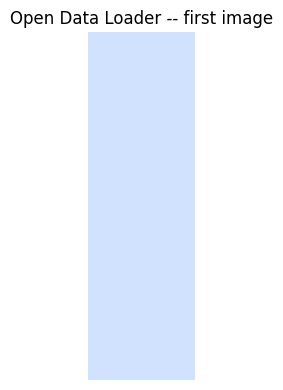

All images saved in: /content/drive/MyDrive/PDF_Data_Extraction/outputs/open_data_loader/5_ibm-annual-report-2025/images


In [69]:
# ── Table preview ─────────────────────────────────────────────────
if odl_tables:
    print(f"First table ({len(odl_tables[0])} rows):")
    print(pd.DataFrame(odl_tables[0]).to_string(index=False, header=False))
else:
    print("No tables found in metadata.")
    print("Tip: set use_ai_table=True in PDFLoader for AI-based table extraction.")

# ── Image preview ─────────────────────────────────────────────────
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img); plt.axis("off")
    plt.title("Open Data Loader -- first image")
    plt.tight_layout(); plt.show()
    print(f"All images saved in: {dirs['images']}")
else:
    print("No images found.")


In [60]:
# ── SCORES ────────────────────────────────────────────────────────
pred_tbl = odl_tables[0] if odl_tables else []
show_scores(TOOL, odl_text, pred_tbl, elapsed_odl)

NameError: name 'show_scores' is not defined